In [1]:
import numpy as np
import pandas as pd
import warnings
import anndata as ad
from torch.utils.data import Dataset
from vinson.loss import binomial_mixture_normed_loss

In [9]:
variant_file = "/net/seq/data2/projects/mbrannon/vinson/variant_train_adata.h5ad"
variant_adata = ad.read_h5ad(variant_file)

print("variant_adata.var.columns:", variant_adata.var.columns.tolist())


variant_adata.var.columns: ['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'AAF', 'RAF']


In [10]:
import os
import sys
import random
import numpy as np
import anndata as ad
from argparse import ArgumentParser


import torch
import lightning as L
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    LearningRateMonitor,
)

from vinson.utils.helpers import read_configs, save_config, generate_run_name
from vinson.utils.run import (
    datamodule_from_config,
    model_from_config,
    set_global_seed,
    set_worker_seed,
    init_multigpu_trainer,
    fit_model,
)


In [11]:
from vinson.utils.data_formatting import extract_data_from_train_anndata, extract_variant_data_from_anndata
from vinson.datasets.sequence import SequenceEmbedDataset, VariantEmbedDataset

genotype_file = '/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v5/phasing/output/all_phased.bed.gz'
fasta_file = '/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa'

In [12]:
outdir = '/home/mbrannon/tmp/vinsontest'

In [13]:
prev_run_config = os.path.join(outdir, "run_config.yaml")

In [14]:
default_config_path = '/home/mbrannon/.local/src/vinson/train/variant/default_train_variant.config.yaml'

In [15]:
config = read_configs(
        default_config_path,
        custom_config_path=None,
    )

In [16]:
config_path = os.path.join(outdir, "run_config.yaml")

In [17]:
acheckpoint = None
checkpoint = (
        os.path.join(outdir, "checkpoints", "last.ckpt")
        if acheckpoint == "last"
        else acheckpoint
    )

In [18]:
debug = True
trainer_kwargs = {}
if debug:
    trainer_kwargs["limit_train_batches"] = 10
    trainer_kwargs["limit_val_batches"] = 10
    config["logging_params"]["val_check_interval"] = 1.0

In [19]:
callbacks = [
        EarlyStopping(monitor="val_loss", mode="min", min_delta=0.005, patience=10),
        ModelCheckpoint(
            monitor="val_loss",
            mode="min",
            filename="{epoch}-{step}-{val_loss:.2f}",
            dirpath=os.path.join(outdir, "checkpoints"),
            save_top_k=5,
            save_last=True,
        ),
        LearningRateMonitor(),
    ]

In [20]:
logger = CSVLogger(os.path.join(outdir, "logs"))
trainer = L.Trainer(
        logger=logger,
        callbacks=callbacks,
        max_epochs=20,
        accelerator='cpu',
        strategy='auto',
        num_nodes=1,
        devices=1,
        val_check_interval=1.0,
        log_every_n_steps=100,
        gradient_clip_val=1.0,
        reload_dataloaders_every_n_epochs=1,
        num_sanity_val_steps=0,
        **trainer_kwargs,
    )

/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..


In [21]:
dataloader_kwargs = dict(
        num_workers=8,
        pin_memory=False,
        drop_last=True,
        worker_init_fn=set_worker_seed,
        persistent_workers=False
    )

In [22]:
datamodule = datamodule_from_config(
        config,
        anndata_file=variant_file,
        fasta_file=fasta_file,
        genotype_file=genotype_file,
        **dataloader_kwargs,
    )

In [23]:
train_dataset_kwargs = {
        **config.get('data_params', {}),  # optional
        **config.get('train_augmentation_kwargs', {}),
    }

In [24]:
valid_dataset_kwargs = {
        **config.get('data_params', {}),  # optional
        **config.get('validation_augmentation_kwargs', {}),
    }

dataloader_kwargs = {
    'batch_size': config.get('hparams', {}).get('batch_size', 64),
    **dataloader_kwargs,
}

In [25]:
valid_dataset_kwargs

{'reverse_complement': False, 'flip_alleles': False, 'jitter': 0, 'noise': 0}

In [26]:
dataloader_kwargs

{'batch_size': 64,
 'num_workers': 8,
 'pin_memory': False,
 'drop_last': True,
 'worker_init_fn': <function vinson.utils.run.set_worker_seed(worker_id: int)>,
 'persistent_workers': False}

In [27]:
model = model_from_config(config, checkpoint_path=checkpoint)

[INFO] Loading pretrained trunk weights from /net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/vinson_model/2025_11_04_trusting_goldwasser/checkpoints/epoch=3-step=3892051-val_loss=52.76.ckpt


/home/mbrannon/.local/src/vinson/src/vinson/utils/run.py:99: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(trunk_weights, map_location="cpu")


In [28]:
model

VariantEmbedModel(
  (trunk): BassetTrunkEmbed(
    (layer1): Sequential(
      (0): Conv1d(4, 300, kernel_size=(19,), stride=(1,), padding=same)
      (1): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=3, stride=3, padding=1, dilation=1, ceil_mode=False)
    )
    (relu1): ReLU()
    (layer2): Sequential(
      (0): Conv1d(300, 200, kernel_size=(11,), stride=(1,), padding=same)
      (1): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=4, stride=4, padding=1, dilation=1, ceil_mode=False)
    )
    (relu2): ReLU()
    (layer3): Sequential(
      (0): Conv1d(200, 200, kernel_size=(7,), stride=(1,), padding=same)
      (1): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=4, stride=4, padding=1, dilation=1, ceil_mode=False)
    )
    (relu

In [29]:
# Patch the model to use debug version for validation
# model.validation_step = model.debug_validation_step.__get__(model)
# model.training_step = model.debug_training_step.__get__(model)
# Required for Lightning-style datamodules
datamodule.setup(stage="fit")

train_loader = datamodule.train_dataloader()


Loading training data for epochs: 100%|██████████| 1/1 [00:05<00:00,  5.43s/it]


Finished creating train dataloader for epoch: epoch_1


/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [30]:
datamodule

In [32]:
train_dataset = datamodule.train_dataset()
print(f"Number of samples in dataset: {len(train_dataset)}")



Number of samples in dataset: 7450732


Finished creating train dataloader for epoch: epoch_1

--- Batch 0 ---
ohe_seq_ref: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, Inf=False
ohe_seq_alt: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, Inf=False
embed: shape=torch.Size([64, 637]), min=-3.13991379737854, max=2.8015806674957275, NaN=False, Inf=False
ref_counts: shape=torch.Size([64]), min=3.0, max=120.0, NaN=False, Inf=False
total_counts: shape=torch.Size([64]), min=15.0, max=212.0, NaN=False, Inf=False
bad_score: shape=torch.Size([64]), min=1.0, max=3.0, NaN=False, Inf=False
lfc: shape=torch.Size([64]), min=-1.5729597120350973, max=2.5985660280340537, NaN=False, Inf=False
sample_id: type=<class 'list'>, len=64
weight: shape=torch.Size([64]), min=1.0, max=1.0, NaN=False, Inf=False
chrom: type=<class 'list'>, len=64
pos: shape=torch.Size([64]), min=568435, max=239230476, NaN=False, Inf=False
Batch loss: 0.7547813057899475

--- Batch 1 ---
ohe_seq_ref: shape=torch.Size([64, 4, 1344]), min=0.0, 

/home/mbrannon/.local/src/vinson/src/vinson/datasets/sequence.py:263: UserWarning: Skipping ambiguous region at chr13:98861243 for INDIV_0101.
  warnings.warn(


Batch loss: 0.5288039445877075

--- Batch 22 ---
ohe_seq_ref: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, Inf=False
ohe_seq_alt: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, Inf=False
embed: shape=torch.Size([64, 637]), min=-3.0354115962982178, max=2.82165265083313, NaN=False, Inf=False
ref_counts: shape=torch.Size([64]), min=2.0, max=515.0, NaN=False, Inf=False
total_counts: shape=torch.Size([64]), min=15.0, max=1039.0, NaN=False, Inf=False
bad_score: shape=torch.Size([64]), min=1.0, max=2.5, NaN=False, Inf=False
lfc: shape=torch.Size([64]), min=-1.5769437800065509, max=0.6816307237512648, NaN=False, Inf=False
sample_id: type=<class 'list'>, len=64
weight: shape=torch.Size([64]), min=1.0, max=1.0, NaN=False, Inf=False
chrom: type=<class 'list'>, len=64
pos: shape=torch.Size([64]), min=242049, max=209357316, NaN=False, Inf=False
Batch loss: 1.159144639968872

--- Batch 23 ---
ohe_seq_ref: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, I

/home/mbrannon/.local/src/vinson/src/vinson/datasets/sequence.py:263: UserWarning: Skipping ambiguous region at chr10:94363068 for INDIV_0087.
  warnings.warn(


Batch loss: 0.8607050180435181

--- Batch 28 ---
ohe_seq_ref: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, Inf=False
ohe_seq_alt: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, Inf=False
embed: shape=torch.Size([64, 637]), min=-3.183058023452759, max=2.9660651683807373, NaN=False, Inf=False
ref_counts: shape=torch.Size([64]), min=4.0, max=83.0, NaN=False, Inf=False
total_counts: shape=torch.Size([64]), min=15.0, max=162.0, NaN=False, Inf=False
bad_score: shape=torch.Size([64]), min=1.0, max=5.0, NaN=False, Inf=False
lfc: shape=torch.Size([64]), min=-1.5236153082081376, max=1.823834859268063, NaN=False, Inf=False
sample_id: type=<class 'list'>, len=64
weight: shape=torch.Size([64]), min=1.0, max=1.0, NaN=False, Inf=False
chrom: type=<class 'list'>, len=64
pos: shape=torch.Size([64]), min=1101993, max=246566688, NaN=False, Inf=False
Batch loss: 0.8395652770996094

--- Batch 29 ---
ohe_seq_ref: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, I

...

Batch loss: 1.1699026823043823

--- Batch 62 ---
ohe_seq_ref: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, Inf=False
ohe_seq_alt: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, Inf=False
embed: shape=torch.Size([64, 637]), min=-3.1606688499450684, max=2.8015964031219482, NaN=False, Inf=False
ref_counts: shape=torch.Size([64]), min=3.0, max=74.0, NaN=False, Inf=False
total_counts: shape=torch.Size([64]), min=15.0, max=185.0, NaN=False, Inf=False
bad_score: shape=torch.Size([64]), min=1.0, max=3.0, NaN=False, Inf=False
lfc: shape=torch.Size([64]), min=-1.5336957868095444, max=1.4350844857044307, NaN=False, Inf=False
sample_id: type=<class 'list'>, len=64
weight: shape=torch.Size([64]), min=1.0, max=1.0, NaN=False, Inf=False
chrom: type=<class 'list'>, len=64
pos: shape=torch.Size([64]), min=721108, max=232835669, NaN=False, Inf=False
Batch loss: 0.9440963864326477

--- Batch 63 ---
ohe_seq_ref: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, 

/home/mbrannon/.local/src/vinson/src/vinson/datasets/sequence.py:263: UserWarning: Skipping ambiguous region at chr6:31356888 for INDIV_0017.
  warnings.warn(


Batch loss: 0.9119001030921936

--- Batch 71 ---
ohe_seq_ref: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, Inf=False
ohe_seq_alt: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, Inf=False
embed: shape=torch.Size([64, 637]), min=-3.009481191635132, max=2.829174280166626, NaN=False, Inf=False
ref_counts: shape=torch.Size([64]), min=3.0, max=134.0, NaN=False, Inf=False
total_counts: shape=torch.Size([64]), min=15.0, max=431.0, NaN=False, Inf=False
bad_score: shape=torch.Size([64]), min=1.0, max=2.5, NaN=False, Inf=False
lfc: shape=torch.Size([64]), min=-1.5065679989499958, max=1.5729597120350973, NaN=False, Inf=False
sample_id: type=<class 'list'>, len=64
weight: shape=torch.Size([64]), min=1.0, max=1.0, NaN=False, Inf=False
chrom: type=<class 'list'>, len=64
pos: shape=torch.Size([64]), min=72784, max=235047524, NaN=False, Inf=False
Batch loss: 0.7297175526618958

--- Batch 72 ---
ohe_seq_ref: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, In

/home/mbrannon/.local/src/vinson/src/vinson/datasets/sequence.py:263: UserWarning: Skipping ambiguous region at chr12:124361043 for INDIV_0015.
  warnings.warn(


Batch loss: 1.0962023735046387

--- Batch 77 ---
ohe_seq_ref: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, Inf=False
ohe_seq_alt: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, Inf=False
embed: shape=torch.Size([64, 637]), min=-3.1591715812683105, max=2.826871871948242, NaN=False, Inf=False
ref_counts: shape=torch.Size([64]), min=1.0, max=95.0, NaN=False, Inf=False
total_counts: shape=torch.Size([64]), min=15.0, max=202.0, NaN=False, Inf=False
bad_score: shape=torch.Size([64]), min=1.0, max=3.0, NaN=False, Inf=False
lfc: shape=torch.Size([64]), min=-1.894334749958207, max=1.228205129394157, NaN=False, Inf=False
sample_id: type=<class 'list'>, len=64
weight: shape=torch.Size([64]), min=1.0, max=1.0, NaN=False, Inf=False
chrom: type=<class 'list'>, len=64
pos: shape=torch.Size([64]), min=548500, max=235532456, NaN=False, Inf=False
Batch loss: 0.9174113273620605

--- Batch 78 ---
ohe_seq_ref: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, Inf

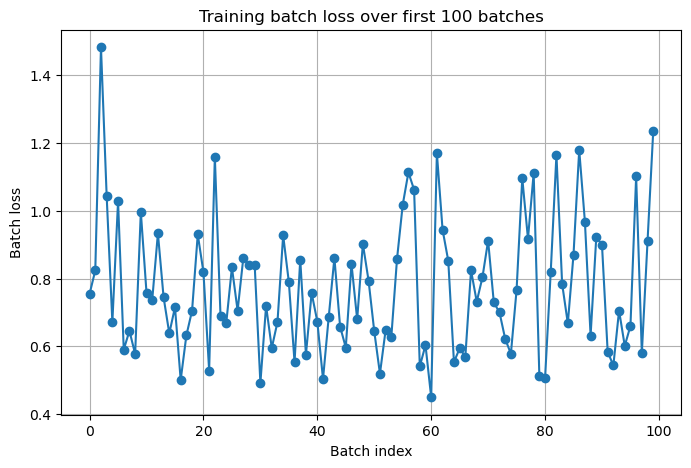

In [96]:
import matplotlib.pyplot as plt

num_batches_to_debug = 100
losses = []

model.eval()  # no gradient updates
with torch.no_grad():
    for batch_idx, batch in enumerate(datamodule.train_dataloader()):
        if batch_idx >= num_batches_to_debug:
            break
        loss = model.debug_training_step(batch, batch_idx)
        losses.append(loss.item())

# Plot the losses
plt.figure(figsize=(8, 5))
plt.plot(range(len(losses)), losses, marker='o')
plt.xlabel("Batch index")
plt.ylabel("Batch loss")
plt.title("Training batch loss over first 100 batches")
plt.grid(True)
plt.show()


In [98]:
fit_model(
        model,
        trainer,
        datamodule,
        checkpoint=checkpoint,
    )


Loading training data for epochs: 100%|██████████| 1/1 [00:11<00:00, 11.20s/it]
/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:658: Checkpoint directory /home/mbrannon/tmp/vinsontest/checkpoints exists and is not empty.

   | Name          | Type             | Params | Mode
-----------------------------------------------------------
0  | trunk         | BassetTrunkEmbed | 1.1 M  | eval
1  | fc1           | Linear           | 5.7 M  | eval
2  | bn1           | BatchNorm1d      | 2.0 K  | eval
3  | dropout1      | Dropout          | 0      | eval
4  | relu1         | ReLU             | 0      | eval
5  | fc2           | Linear           | 1.0 M  | eval
6  | bn2           | BatchNorm1d      | 2.0 K  | eval
7  | dropout2      | Dropout          | 0      | eval
8  | relu2         | ReLU             | 0      | eval
9  | final         | Linear           | 1.0 K  | eval
10 | train_metrics | MetricCollection | 0 

Finished creating train dataloader for epoch: epoch_1


/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (10) is smaller than the logging interval Trainer(log_every_n_steps=100). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Finished creating train dataloader for epoch: epoch_1


...

Validation: |          | 0/? [00:00<?, ?it/s]


--- Validation Batch 0 ---
ohe_seq_ref: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, Inf=False
ohe_seq_alt: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, Inf=False
embed: shape=torch.Size([64, 637]), min=-2.48437237739563, max=2.3048954010009766, NaN=False, Inf=False
ref_counts: shape=torch.Size([64]), min=1.0, max=65.0, NaN=False, Inf=False
total_counts: shape=torch.Size([64]), min=15.0, max=82.0, NaN=False, Inf=False
bad_score: shape=torch.Size([64]), min=1.0, max=5.0, NaN=False, Inf=False
lfc: shape=torch.Size([64]), min=-1.4163265788200854, max=1.0782034333586912, NaN=False, Inf=False
sample_id: type=<class 'list'>, len=64
weight: shape=torch.Size([64]), min=1.0, max=1.0, NaN=False, Inf=False
chrom: type=<class 'list'>, len=64
pos: shape=torch.Size([64]), min=11974185, max=131279474, NaN=False, Inf=False
Validation batch loss: 0.5184625387191772

--- Validation Batch 1 ---
ohe_seq_ref: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, I

/home/mbrannon/.local/src/vinson/src/vinson/datasets/sequence.py:263: UserWarning: Skipping ambiguous region at chr22:17798032 for INDIV_0002.
  warnings.warn(


Validation batch loss: 0.7323571443557739

--- Validation Batch 8 ---
ohe_seq_ref: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, Inf=False
ohe_seq_alt: shape=torch.Size([64, 4, 1344]), min=0.0, max=1.0, NaN=False, Inf=False
embed: shape=torch.Size([64, 637]), min=-2.410264015197754, max=2.3152875900268555, NaN=False, Inf=False
ref_counts: shape=torch.Size([64]), min=0.0, max=82.0, NaN=False, Inf=False
total_counts: shape=torch.Size([64]), min=15.0, max=123.0, NaN=False, Inf=False
bad_score: shape=torch.Size([64]), min=1.0, max=5.0, NaN=False, Inf=False
lfc: shape=torch.Size([64]), min=-4.859812318041723, max=1.228205129394157, NaN=False, Inf=False
sample_id: type=<class 'list'>, len=64
weight: shape=torch.Size([64]), min=1.0, max=1.0, NaN=False, Inf=False
chrom: type=<class 'list'>, len=64
pos: shape=torch.Size([64]), min=11974031, max=131278433, NaN=False, Inf=False
Validation batch loss: 0.7024204134941101

--- Validation Batch 9 ---
ohe_seq_ref: shape=torch.Size([64,

RuntimeError: Early stopping conditioned on metric `val_loss` which is not available. Pass in or modify your `EarlyStopping` callback to use any of the following: `lr-AdamW`

In [ ]:
import torch
import math

# Required for Lightning-style datamodules
datamodule.setup(stage="fit")

train_loader = datamodule.train_dataloader()


# print("===== Scanning all batches for NaN/Inf =====")

# for batch_i, batch in enumerate(train_loader):
#     # Forward pass
#     logits = model(
#         batch["ohe_seq_ref"],
#         batch["ohe_seq_alt"],
#         batch["embed"]
#     )

#     target = batch["ref_counts"]
#     n = batch["total_counts"]
#     bad_score = batch["bad_score"]

#     # Compute elementwise loss (no reduction)
#     elem_loss = binomial_mixture_normed_loss(
#         logits, target, n, bad_score, tau=0, reduction="none"
#     )

#     # Find any NaN or Inf
#     bad_idx = torch.where(torch.isnan(elem_loss) | torch.isinf(elem_loss))[0]

#     if len(bad_idx) > 0:
#         print(f"\n===== FAILURE at batch {batch_i} =====")
#         print("Bad indices:", bad_idx.tolist())

#         for idx in bad_idx:
#             print(f"\n--- Problem sample at idx {idx.item()} ---")
            
#             # Print only numeric info
#             print("logit =", logits[idx])
#             print("sigmoid(logit) =", torch.sigmoid(logits[idx]))
#             print("ref_counts =", target[idx])
#             print("total_counts =", n[idx])
#             print("k/n =", target[idx].float() / n[idx].float())
#             print("bad_score =", bad_score[idx])

#         print("\nStopping scan because failure located.")
#         break

# else:
#     print("\n===== Scan Complete: NO NaN/Inf FOUND =====")


In [ ]:
print("===== Scanning all batches (printing loss stats every iteration) =====")

for batch_i, batch in enumerate(train_loader):
    logits = model(
        batch["ohe_seq_ref"],
        batch["ohe_seq_alt"],
        batch["embed"]
    )

    target = batch["ref_counts"]
    n = batch["total_counts"]
    bad_score = batch["bad_score"]

    elem_loss = binomial_mixture_normed_loss(
        logits, target, n, bad_score, tau=0, reduction="none"
    )

    # Basic stats
    num = elem_loss.numel()
    num_nan = torch.isnan(elem_loss).sum().item()
    num_inf = torch.isinf(elem_loss).sum().item()

    finite = elem_loss[torch.isfinite(elem_loss)]

    print(
        f"[batch {batch_i:04d}] "
        f"loss: min={finite.min().item():.4f} "
        f"max={finite.max().item():.4f} "
        f"mean={finite.mean().item():.4f} | "
        f"NaN={num_nan} Inf={num_inf}"
    )

    if num_nan > 0 or num_inf > 0:
        print("⚠️  Numerical issue detected in this batch")

        bad_idx = torch.where(
            torch.isnan(elem_loss) | torch.isinf(elem_loss)
        )[0]

        for idx in bad_idx[:3]:  # cap prints
            print(f"  idx {idx.item()} | "
                  f"logit={logits[idx].item():.4f} "
                  f"k={target[idx].item()} "
                  f"n={n[idx].item()} "
                  f"k/n={(target[idx]/n[idx]).item():.4f} "
                  f"bad_score={bad_score[idx].item():.4f} "
                  f"loss={elem_loss[idx].item()}")

        break


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# batch_csv = "/net/seq/data2/projects/mbrannon/variant_model_test/2026_02_03_admiring_curie/batch_logs/batch_debug.csv"
batch_csv = "/net/seq/data2/projects/mbrannon/variant_model_test/2026_02_06_clever_ritchie/batch_logs/batch_debug.csv"
metrics_csv = "/net/seq/data2/projects/mbrannon/variant_model_test/2026_02_06_pensive_saha/logs/lightning_logs/version_0/metrics.csv"
### good

batch_df = pd.read_csv(batch_csv)
metrics_df = pd.read_csv(metrics_csv)


In [2]:
batch_df

,epoch,batch_idx,loss,min_lfc,max_lfc,min_ref_counts,max_ref_counts,min_total_counts,max_total_counts,min_bad_score,max_bad_score


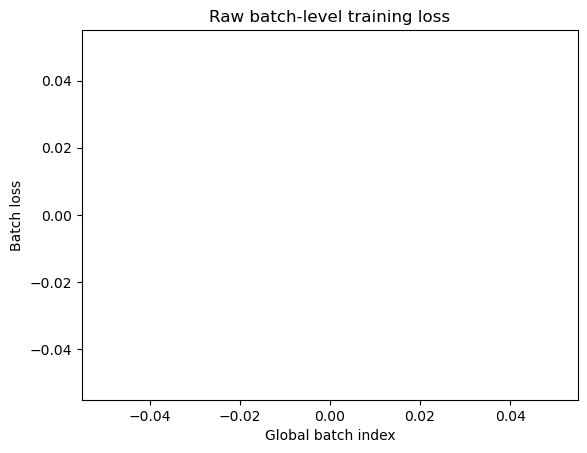

In [3]:
batch_df["global_batch"] = range(len(batch_df))

plt.figure()
plt.plot(batch_df["global_batch"], batch_df["loss"])
plt.xlabel("Global batch index")
plt.ylabel("Batch loss")
plt.title("Raw batch-level training loss")
plt.show()


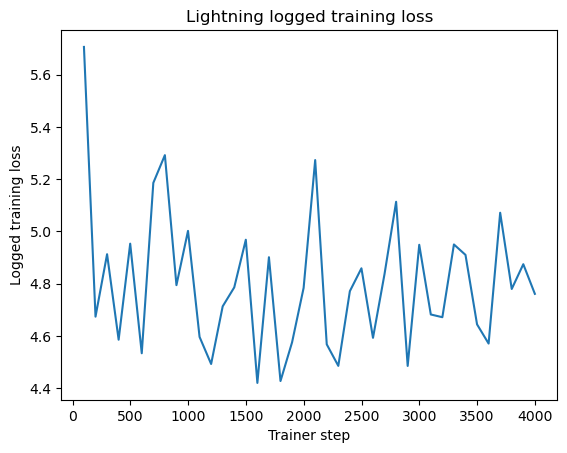

In [4]:
train_loss_df = metrics_df.dropna(subset=["loss"])

plt.figure()
plt.plot(train_loss_df["step"], train_loss_df["loss"])
plt.xlabel("Trainer step")
plt.ylabel("Logged training loss")
plt.title("Lightning logged training loss")
plt.show()


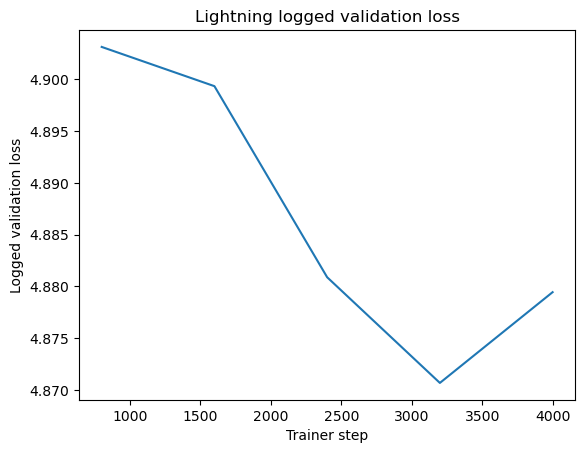

In [5]:
val_loss_df = metrics_df.dropna(subset=["val_loss"])

plt.figure()
plt.plot(val_loss_df["step"], val_loss_df["val_loss"])
plt.xlabel("Trainer step")
plt.ylabel("Logged validation loss")
plt.title("Lightning logged validation loss")
plt.show()


In [41]:
train_loss_df

,epoch,loss,lr-AdamW,step,val_loss,val_pcc
4,1.0,5.249122,NaN,99,NaN,NaN


In [60]:
change_stop = '/net/seq/data2/projects/mbrannon/variant_model_vinson/2025_12_16_epic_yonath/logs/lightning_logs//version_0/metrics.csv'

In [61]:
new_df = pd.read_csv(change_stop)

In [62]:
new_df

,epoch,loss,lr-AdamW,step,val_loss
0,NaN,NaN,0.001,0,NaN
1,NaN,NaN,0.001,99,NaN
2,0.0,0.834514,NaN,99,NaN
3,NaN,NaN,0.001,199,NaN
4,0.0,0.955545,NaN,199,NaN
...,...,...,...,...,...
185,NaN,NaN,0.001,9299,NaN
186,0.0,0.688535,NaN,9299,NaN
187,0.0,NaN,NaN,9346,0.834251
188,NaN,NaN,0.001,9399,NaN


In [6]:
!pwd

/home/mbrannon/.local/src/vinson


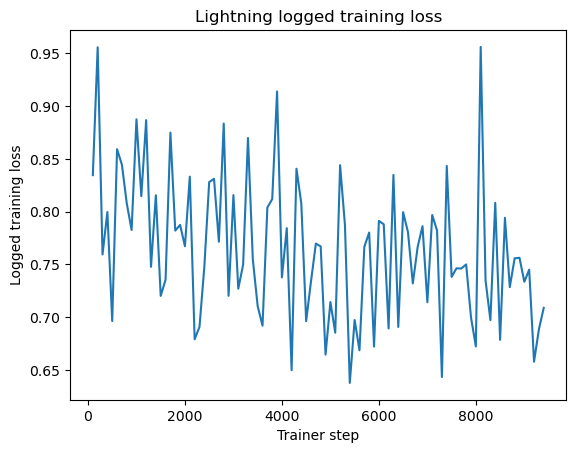

In [66]:
train_loss_df = new_df.dropna(subset=["loss"])

plt.figure()
plt.plot(train_loss_df["step"], train_loss_df["loss"])
plt.xlabel("Trainer step")
plt.ylabel("Logged training loss")
plt.title("Lightning logged training loss")
plt.show()


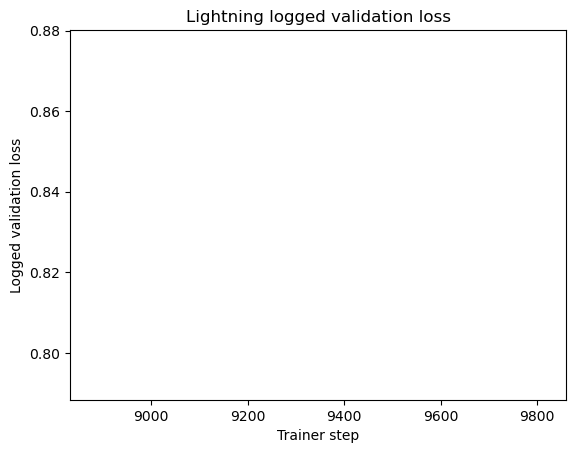

In [67]:
val_loss_df = new_df.dropna(subset=["val_loss"])

plt.figure()
plt.plot(val_loss_df["step"], val_loss_df["val_loss"])
plt.xlabel("Trainer step")
plt.ylabel("Logged validation loss")
plt.title("Lightning logged validation loss")
plt.show()


In [68]:
new_df

,epoch,loss,lr-AdamW,step,val_loss
0,NaN,NaN,0.001,0,NaN
1,NaN,NaN,0.001,99,NaN
2,0.0,0.834514,NaN,99,NaN
3,NaN,NaN,0.001,199,NaN
4,0.0,0.955545,NaN,199,NaN
...,...,...,...,...,...
185,NaN,NaN,0.001,9299,NaN
186,0.0,0.688535,NaN,9299,NaN
187,0.0,NaN,NaN,9346,0.834251
188,NaN,NaN,0.001,9399,NaN


In [2]:
import torch

checkpoint_path = "/home/mbrannon/.local/src/vinson/train/variant/legnetNOV03_checkpoint.ckpt"

import torch
ckpt = torch.load(checkpoint_path, map_location="cpu")
print(ckpt['hyper_parameters'])


{'lr_scheduler': 'OneCycleLR', 'optimizer_kwargs': {'weight_decay': 0.01}, 'lr_scheduler_kwargs': {'max_lr': 0.001, 'div_factor': 25, 'final_div_factor': 10000, 'total_steps': 729763}, 'init_weights': True, 'log_output': False, 'n_tasks': 1, 'regression': True}


/tmp/slurm.10048126/ipykernel_586684/1345143951.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location="cpu")


In [6]:
state_dict = torch.load(checkpoint_path, map_location="cpu")['state_dict']
print(state_dict.keys())

odict_keys(['trunk_model.stem.convs_list.0.weight', 'trunk_model.stem.convs_list.1.weight', 'trunk_model.stem.convs_list.2.weight', 'trunk_model.stem.convs_list.3.weight', 'trunk_model.blocks_dict.blc0.0.weight', 'trunk_model.blocks_dict.blc0.0.bias', 'trunk_model.blocks_dict.blc0.0.running_mean', 'trunk_model.blocks_dict.blc0.0.running_var', 'trunk_model.blocks_dict.blc0.0.num_batches_tracked', 'trunk_model.blocks_dict.blc0.2.fn.block.0.weight', 'trunk_model.blocks_dict.blc0.2.fn.block.1.weight', 'trunk_model.blocks_dict.blc0.2.fn.block.1.bias', 'trunk_model.blocks_dict.blc0.2.fn.block.1.running_mean', 'trunk_model.blocks_dict.blc0.2.fn.block.1.running_var', 'trunk_model.blocks_dict.blc0.2.fn.block.1.num_batches_tracked', 'trunk_model.blocks_dict.blc0.2.fn.block.3.weight', 'trunk_model.blocks_dict.blc0.2.fn.block.4.weight', 'trunk_model.blocks_dict.blc0.2.fn.block.4.bias', 'trunk_model.blocks_dict.blc0.2.fn.block.4.running_mean', 'trunk_model.blocks_dict.blc0.2.fn.block.4.running_var'

/tmp/slurm.10048126/ipykernel_586684/428187341.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path, map_location="cpu")['state_dict']